# Lecture examples

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn import datasets, decomposition

In [ ]:
data = pd.read_csv('titanic.csv')

In [ ]:
data.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Text(0.5, 1.0, 'Count of passengers by age')

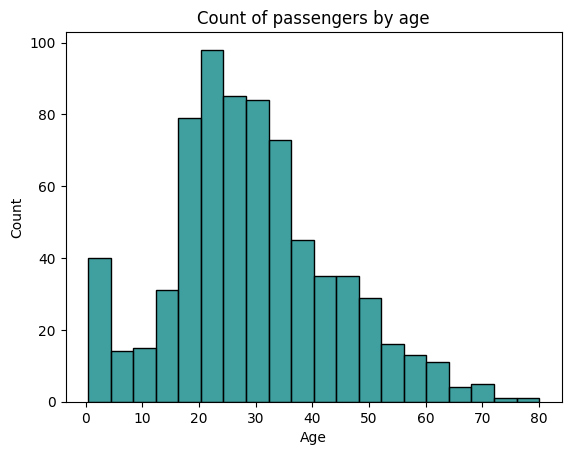

In [ ]:
sns.histplot(data, x='Age', color='teal').set_title('Count of passengers by age')

Text(0.5, 1.0, 'Count of passengers by gender')

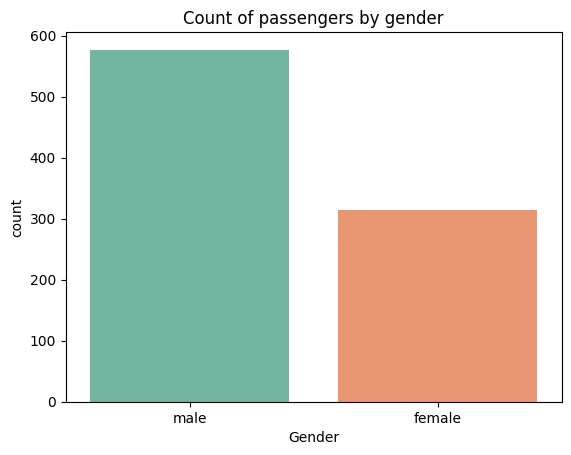

In [ ]:
sns.countplot(data, x='Gender', hue='Gender', palette='Set2').set_title('Count of passengers by gender')

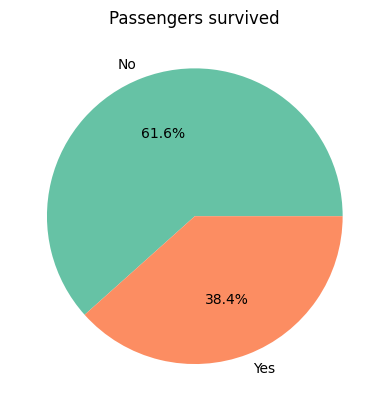

In [ ]:
x = data['Survived'].value_counts()

colors = sns.color_palette("Set2")

plt.pie(x.values,
        labels=['No', 'Yes'],
        labeldistance=1.1,
        autopct='%1.1f%%',
        colors=colors)

plt.title("Passengers survived")

plt.show()

Text(0.5, 1.0, 'Survival vs Fare')

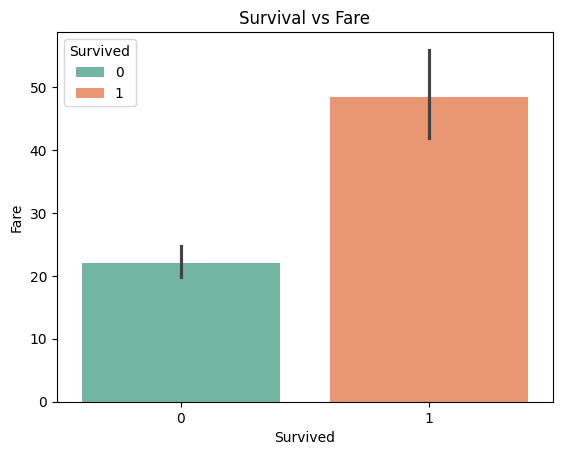

In [ ]:
sns.barplot(data, x='Survived', y='Fare', hue='Survived', palette='Set2').set_title('Survival vs Fare')

Text(0.5, 1.0, 'Age vs Fare')

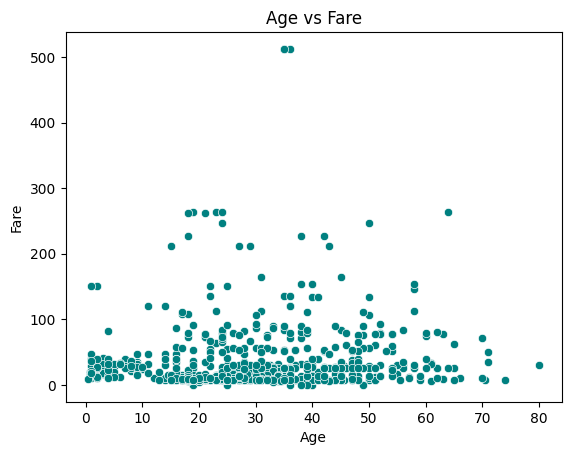

In [ ]:
sns.scatterplot(data, x='Age', y='Fare', color='teal').set_title('Age vs Fare')

<Axes: xlabel='Gender', ylabel='count'>

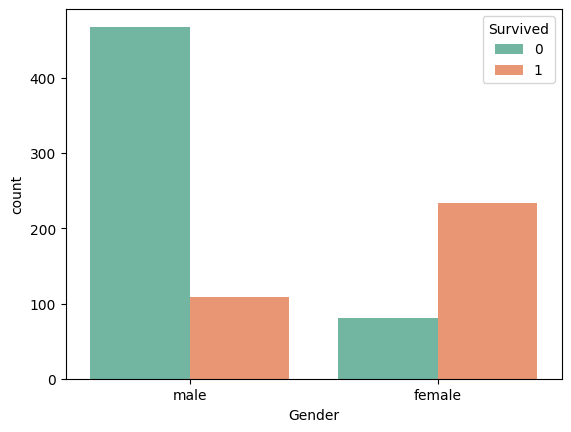

In [ ]:
sns.countplot(data, x='Gender', hue='Survived', palette='Set2')

In [ ]:
iris = datasets.load_iris()
iris_df = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])

In [ ]:
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


Text(0.5, 1.0, 'Iris features correlation')

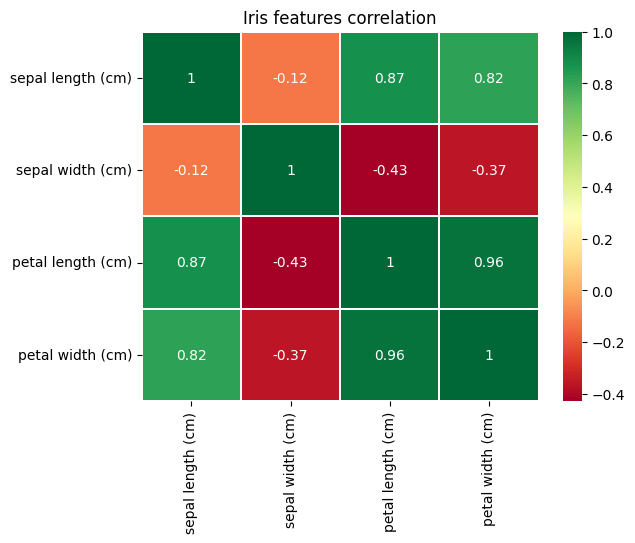

In [ ]:
sns.heatmap(iris_df.drop(['target'],axis=1).corr(),annot=True,cmap='RdYlGn',linewidths=0.2).set_title('Iris features correlation')

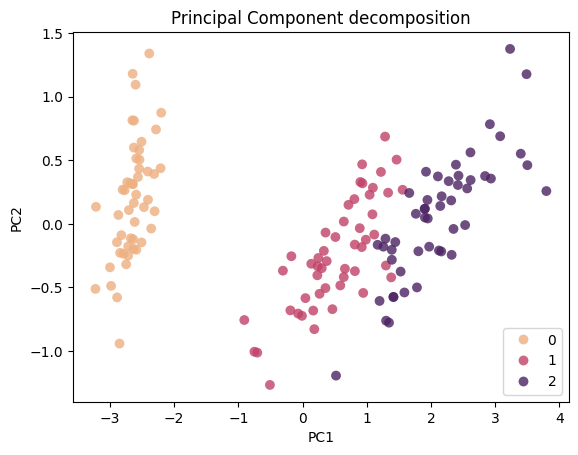

In [ ]:
# divide datasets to features and labels
X = iris.data
y = iris.target

# define PCA
pca = decomposition.PCA(n_components=2)
X_tr = pca.fit_transform(X)

# visualize
ax = sns.scatterplot(x=X_tr[:, 0], y=X_tr[:, 1], hue=y, palette="flare",
                     s=50, linewidth=0, alpha=0.8)

ax.set(xlabel='PC1', ylabel='PC2')
plt.title('Principal Component decomposition')
plt.show()

([<matplotlib.axis.XTick at 0x7eba0e5257b0>,
 [Text(0, 0, 'PC1'), Text(1, 0, 'PC2'), Text(2, 0, 'PC3'), Text(3, 0, 'PC4')])

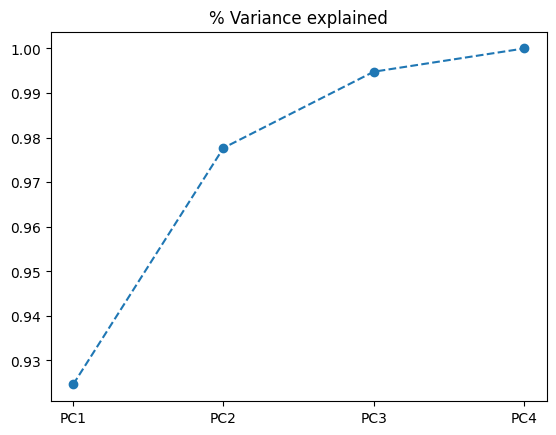

In [ ]:
pca_full = decomposition.PCA(n_components=4)
X_full = pca_full.fit_transform(X)

plt.plot(pca_full.explained_variance_ratio_.cumsum(), marker='o', linestyle='--')
plt.title('% Variance explained')
plt.xticks(np.arange(4), ['PC1', 'PC2', 'PC3', 'PC4'])

# Titanic dataset in-depth analysis

## Introduction

https://www.kaggle.com/competitions/titanic


> *On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren't enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.*
> *While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.*


In this challenge, we ask you to build a predictive model that answers the question: **“what sorts of people were more likely to survive?”** using passenger data (ie name, age, gender, socio-economic class, etc).




In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [ ]:
data = pd.read_csv('titanic.csv')

In [ ]:
data.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# checking for total null values

data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**The Age, Cabin and Embarked have null values.** We will deal with that later.

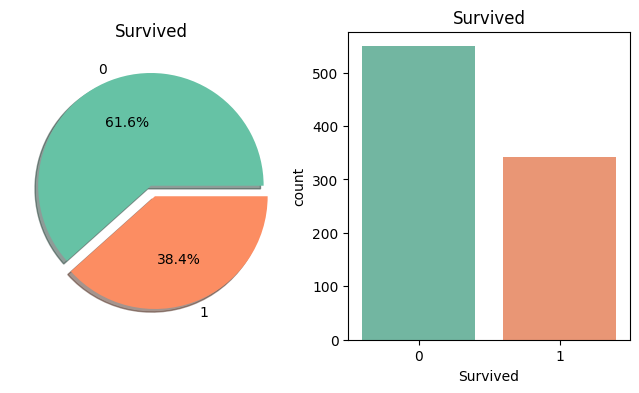

In [ ]:
# Check how many survived

# Create subplots
f, ax = plt.subplots(1, 2, figsize=(8, 4))

# Piechart for the first subplot
data['Survived'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True, colors=sns.color_palette('Set2'))
ax[0].set_title('Survived')
ax[0].set_ylabel('')

# Countplot for the second subplot
sns.countplot(data, x='Survived', ax=ax[1], palette='Set2')
ax[1].set_title('Survived')

plt.show()

It is evident that **not many passengers survived the accident**.

Out of 891 passengers in training set, only around 350 survived i.e **Only 38.4% of the total training set survived the crash**. We need to dig down more to get better insights from the data and see which categories of the passengers did survive and who didn't.

We will try to check the survival rate by using the different features of the dataset. Some of the features being Gender, Port Of Embarkation, Age, etc.

First let us understand the different types of features.

## Feature types

1. **Categorical Features:**
A categorical variable is one that has two or more categories and each value in that feature can be categorised by them.For example, gender is a categorical variable having two categories (male and female). Now we cannot sort or give any ordering to such variables. They are also known as Nominal Variables. **Categorical Features in the dataset: Gender, Embarked.**

2. **Ordinal Features:**
An ordinal variable is similar to categorical values, but the difference between them is that we can have relative ordering or sorting between the values. For eg: If we have a feature like Height with values Tall, Medium, Short, then Height is a ordinal variable. Here we can have a relative sort in the variable. **Ordinal Features in the dataset: PClass**

3. **Continous Feature:**
A feature is said to be continous if it can take values between any two points or between the minimum or maximum values in the features column. **Continous Features in the dataset: Age**

### Gender

In [ ]:
# Gender -> categorical feature

pd.crosstab(data.Gender, data.Survived, margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Gender,,,
female,81,233,314
male,468,109,577
All,549,342,891


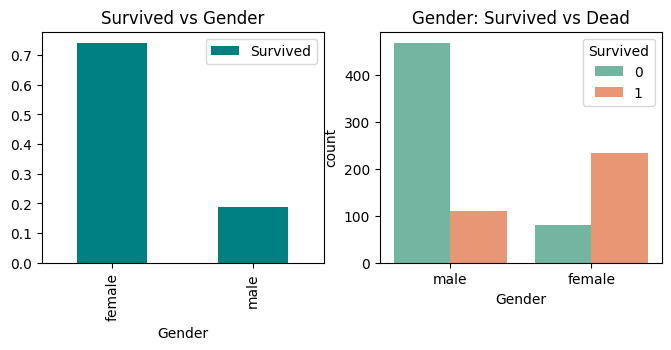

In [ ]:
f, ax=plt.subplots(1, 2, figsize=(8,3))

data[['Gender','Survived']].groupby(['Gender']).mean().plot.bar(ax=ax[0], color='teal')
ax[0].set_title('Survived vs Gender')

sns.countplot(data, x='Gender',hue='Survived', ax=ax[1], palette='Set2')
ax[1].set_title('Gender: Survived vs Dead')

plt.show()

The number of men on the ship is lot more than the number of women. Still the number of women saved is almost twice the number of males saved. **The survival rates for a women on the ship is around 75% while that for men in around 18-19%.**

This looks to be a very important feature for modeling.

### Pclass

In [ ]:
# Pclass -> ordinal feature

pd.crosstab(data.Pclass, data.Survived, margins=True).style.background_gradient(cmap='summer_r')

Survived,0,1,All
Pclass,,,
1,80,136,216
2,97,87,184
3,372,119,491
All,549,342,891


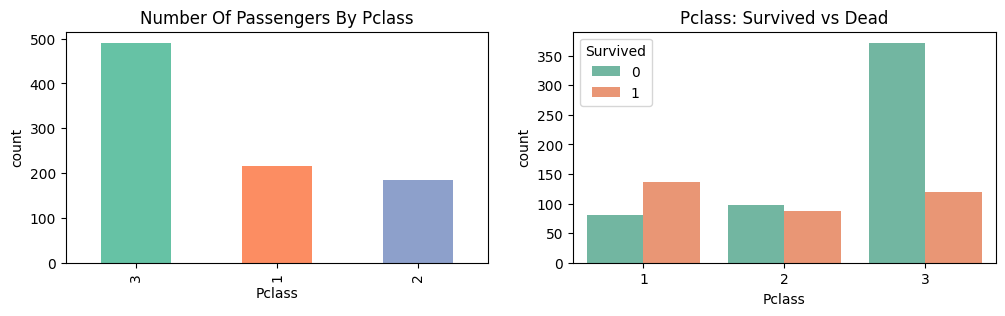

In [ ]:
f, ax = plt.subplots(1, 2, figsize=(12,3))

data['Pclass'].value_counts().plot.bar(color=sns.color_palette('Set2'), ax=ax[0])
ax[0].set_title('Number Of Passengers By Pclass')
ax[0].set_ylabel('count')

sns.countplot(data, x='Pclass', hue='Survived', ax=ax[1], palette='Set2')
ax[1].set_title('Pclass: Survived vs Dead')

plt.show()

We can clearly see that **passenegers of Pclass 1 were given a very high priority while rescue**. Even though the the number of passengers in Pclass 3 were a lot higher, still the number of survival from them is very low, somewhere around 25%.

For Pclass 1 survival rate is around 63% while for Pclass2 is around 48%.

Lets dive in little bit more and check for other interesting observations. Lets check survival rate with Gender and Pclass together.

In [ ]:
pd.crosstab([data.Gender,data.Survived], data.Pclass, margins=True).style.background_gradient(cmap='summer_r')

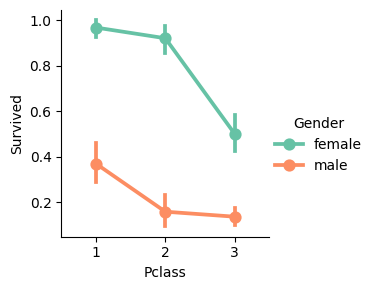

In [ ]:
sns.catplot(data, x='Pclass', y='Survived', hue='Gender', palette='Set2',
            kind="point", height=3, aspect=1)

We use CatPlot in this case, because **it makes the seperation of categorical values easy**.

Looking at the CrossTab and the CatPlot, we can easily infer that survival for women from Pclass1 is about 95-96%, as only 3 out of 94 women from Pclass1 died.

It is evident that irrespective of Pclass, women were given first priority while rescue. Even men from Pclass1 have a very low survival rate.

Looks like Pclass is also an important feature.

### Age

In [ ]:
# Age -> continuous feature

print('Oldest Passenger was of:',data['Age'].max(),'Years')
print('Youngest Passenger was of:',data['Age'].min(),'Years')
print('Average Age on the ship:',data['Age'].mean(),'Years')

Oldest Passenger was of: 80.0 Years
Youngest Passenger was of: 0.42 Years
Average Age on the ship: 29.69911764705882 Years


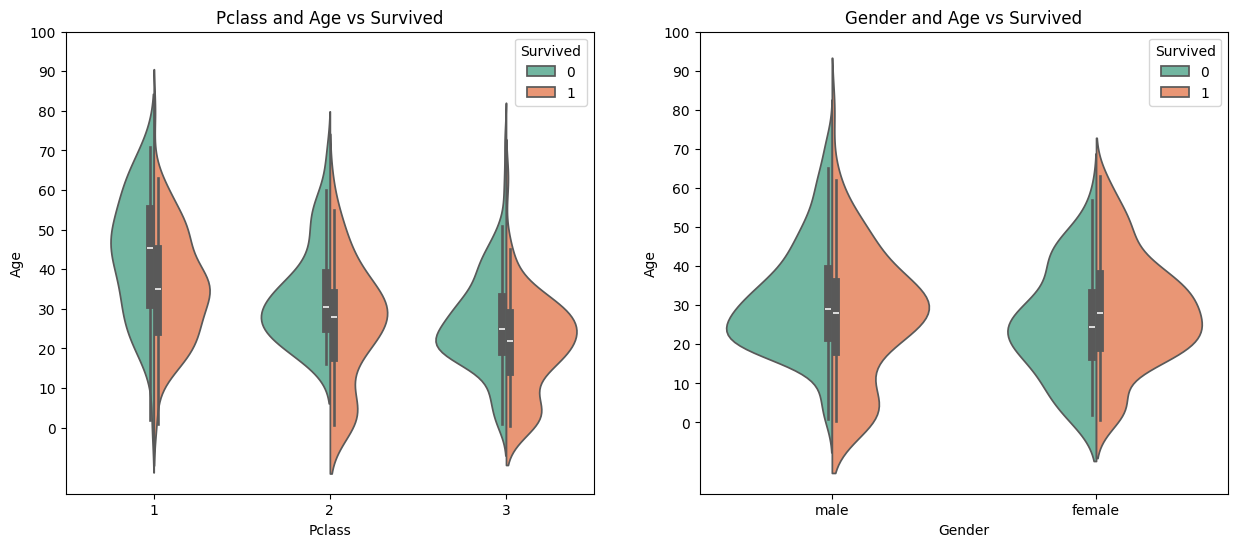

In [ ]:
f, ax=plt.subplots(1,2, figsize=(15,6))

sns.violinplot(data, x="Pclass", y="Age", hue="Survived", split=True, ax=ax[0], palette="Set2")
ax[0].set_title('Pclass and Age vs Survived')
ax[0].set_yticks(range(0, 110, 10))

sns.violinplot(data, x="Gender", y="Age", hue="Survived", split=True, ax=ax[1], palette="Set2")
ax[1].set_title('Gender and Age vs Survived')
ax[1].set_yticks(range(0, 110, 10))

plt.show()

Observations so far:

1. The number of children increases with Pclass and the survival rate for passenegers below Age 10 (i.e children) looks to be good irrespective of the Pclass.

2. Survival chances for Passenegers aged 20-50 from Pclass1 is high and is even better for women.

3. For males, the survival chances decreases with an increase in age.

Remember the **Age feature has 177 null values**. To replace these NaN values, we can assign them the mean age of the dataset.

But the problem is, there were many people with many different ages. We just can't assign a 4 year kid with the mean age that is 29 years. We can also check the Name feature. Looking upon the feature, we can see that the names have a salutation like Mr or Mrs. Thus we can assign the mean values of Mr and Mrs to the respective groups.

In [ ]:
# Extract the salutations

data['Initial']=0
for i in data:
    data['Initial']=data.Name.str.extract('([A-Za-z]+)\.')

In [ ]:
# Checking the initials with the Gender

pd.crosstab(data.Initial, data.Gender).T.style.background_gradient(cmap='summer_r')

Initial,Capt,Col,Countess,Don,Dr,Jonkheer,Lady,Major,Master,Miss,Mlle,Mme,Mr,Mrs,Ms,Rev,Sir
Gender,,,,,,,,,,,,,,,,,
female,0,0,1,0,1,0,1,0,0,182,2,1,0,125,1,0,0
male,1,2,0,1,6,1,0,2,40,0,0,0,517,0,0,6,1


In [ ]:
data['Initial'].replace(['Mlle','Mme','Ms','Dr','Major','Lady','Countess','Jonkheer','Col','Rev','Capt','Sir','Don'],
                        ['Miss','Mrs','Miss','Mr','Mr','Mrs','Mrs','Mr','Mr','Mr','Mr','Mr','Mr'], inplace=True)

In [ ]:
# Check the average Age by initials

data.groupby('Initial')['Age'].mean()

Initial
Master     4.574167
Miss      21.845638
Mr        33.022727
Mrs       35.873874
Name: Age, dtype: float64

In [ ]:
# Assigning the NaN Values with the Ceil values of the mean ages

data.loc[(data.Age.isnull())&(data.Initial=='Mr'),'Age']=33
data.loc[(data.Age.isnull())&(data.Initial=='Mrs'),'Age']=36
data.loc[(data.Age.isnull())&(data.Initial=='Master'),'Age']=5
data.loc[(data.Age.isnull())&(data.Initial=='Miss'),'Age']=22

In [ ]:
 # No null values left finally

data.Age.isnull().any()

False

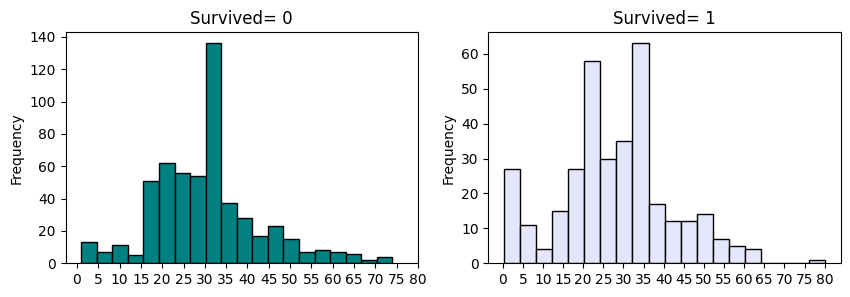

In [ ]:
f, ax=plt.subplots(1,2,figsize=(10,3))

data[data['Survived']==0].Age.plot.hist(ax=ax[0], bins=20, edgecolor='black', color='teal')
ax[0].set_title('Survived= 0')
x1=list(range(0,85,5))
ax[0].set_xticks(x1)

data[data['Survived']==1].Age.plot.hist(ax=ax[1], color='lavender', bins=20, edgecolor='black')
ax[1].set_title('Survived= 1')
x2=list(range(0,85,5))
ax[1].set_xticks(x2)

plt.show()

Observations:
1. The toddlers(less than 5 years) were saved in large numbers ("The women and child first" policy).

2. The oldest passenger was saved (80 years).

3. Maximum number of deaths were in the age group of 30-40.

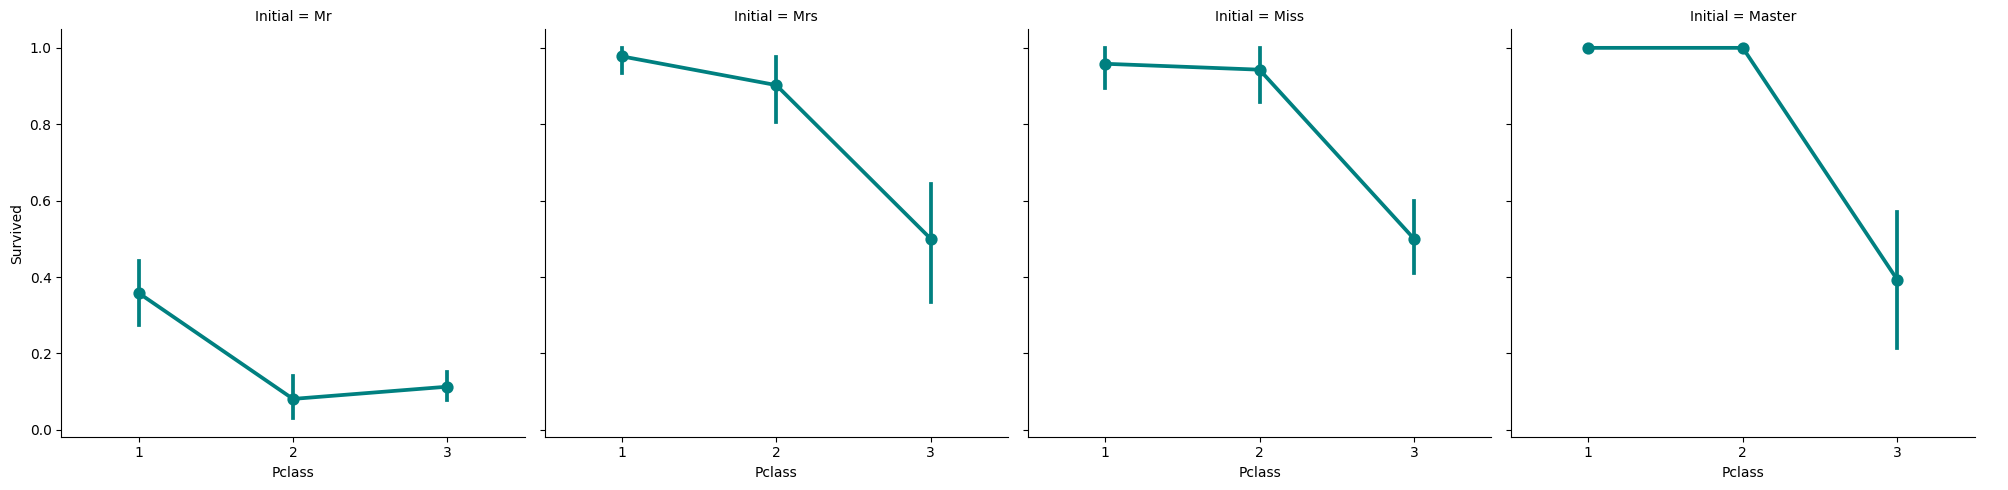

In [ ]:
sns.catplot(data, x='Pclass', y='Survived', col='Initial', kind='point', color='teal')

"The women and child first" policy thus holds true **irrespective of the class.**

### Embarked

In [ ]:
# Embarked -> categorical value

pd.crosstab([data.Embarked, data.Pclass],[data.Gender, data.Survived], margins=True).style.background_gradient(cmap='summer_r')

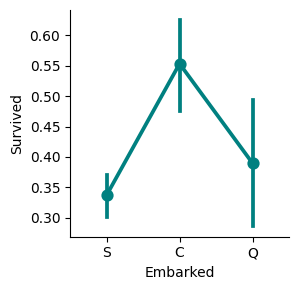

In [ ]:
sns.catplot(data, x='Embarked', y='Survived', kind='point',
            color='teal', height=3, aspect=1)

The chances for survival for Port C is highest around 0.55 while it is lowest for S.

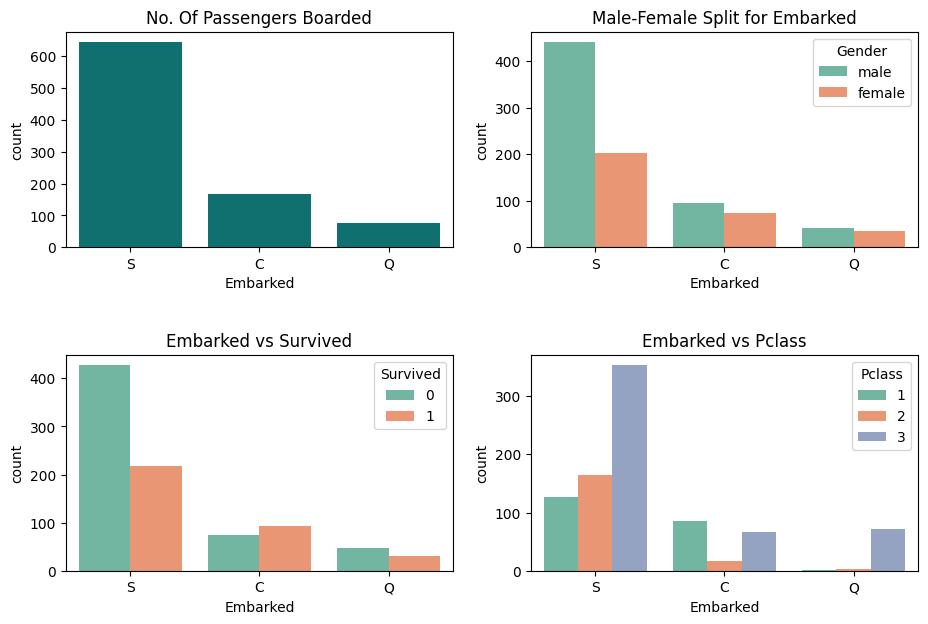

In [ ]:
f, ax=plt.subplots(2,2, figsize=(11,7))

sns.countplot(data, x='Embarked', ax=ax[0,0], color='teal')
ax[0,0].set_title('No. Of Passengers Boarded')

sns.countplot(data, x='Embarked',hue='Gender', ax=ax[0,1], palette='Set2')
ax[0,1].set_title('Male-Female Split for Embarked')

sns.countplot(data, x='Embarked', hue='Survived', ax=ax[1,0], palette='Set2')
ax[1,0].set_title('Embarked vs Survived')

sns.countplot(data, x='Embarked', hue='Pclass', ax=ax[1,1], palette='Set2')
ax[1,1].set_title('Embarked vs Pclass')

plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

Observations:

1. Maximum passengers boarded from S. Majority of them being from Pclass3.

2. The passengers from C look to be lucky as a good proportion of them survived. The reason for this maybe the rescue of all the Pclass1 and Pclass2 passengers.

3. The Embark S looks to the port from where majority of the rich people boarded. Still the chances for survival is low here, that is because many passengers from Pclass3 around 81% didn't survive.

4. Port Q had almost 95% of the passengers were from Pclass3.

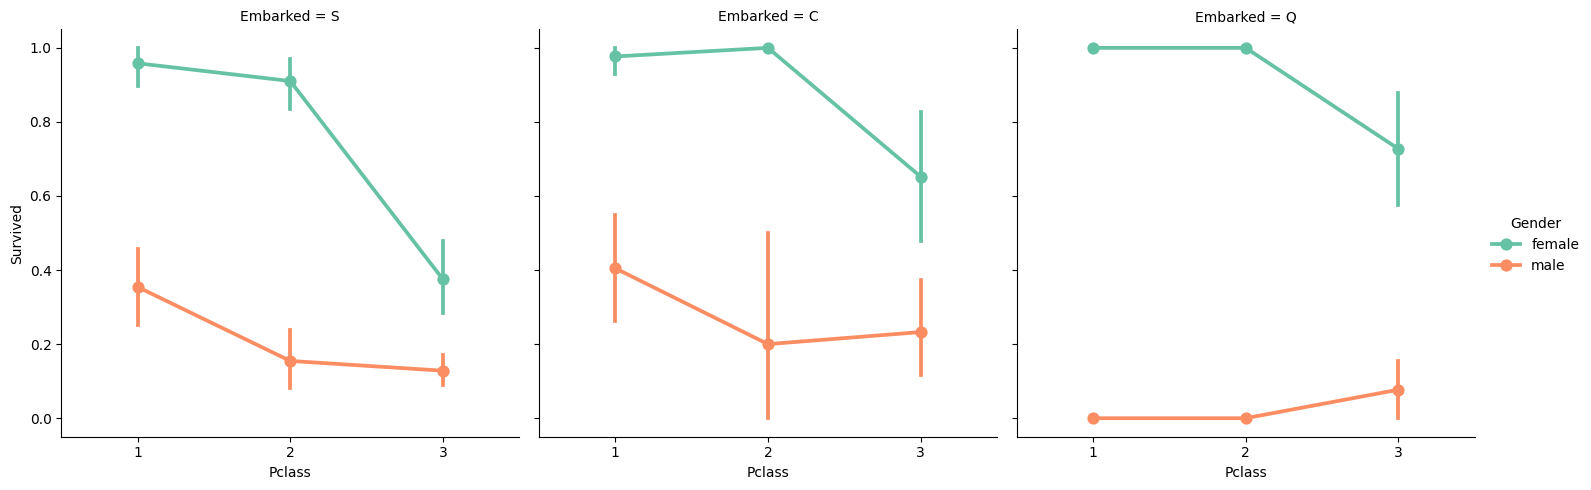

In [ ]:
sns.catplot(data, x='Pclass', y='Survived', hue='Gender', col='Embarked', kind='point', palette='Set2')

Observations:

1. The survival chances are almost 1 for women for Pclass1 and Pclass2 irrespective of the Pclass.

2. Port S looks to be very unlucky for Pclass3 passengers as the survival rate for both men and women is very low.

3. Port Q looks looks to be the most unlucky one for men, as almost all were from Pclass 3.

In [ ]:
# Filling Embarked NaN
# Maximum passengers boarded from Port S -> replace NaN with S

data['Embarked'].fillna('S', inplace=True)

In [ ]:
# Finally No NaN values

data.Embarked.isnull().any()

False

### SibSp / ParCh

In [ ]:
# SibSp -> discrete value

pd.crosstab([data.SibSp],data.Survived).style.background_gradient(cmap='summer_r')

Survived,0,1
SibSp,,
0,398,210
1,97,112
2,15,13
3,12,4
4,15,3
5,5,0
8,7,0


Text(0.5, 1.0, 'SibSp vs Survived')

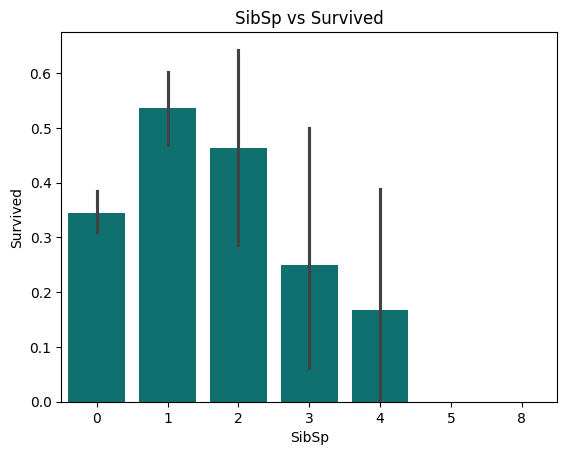

In [ ]:
sns.barplot(data, x='SibSp', y='Survived', color='teal').set_title('SibSp vs Survived')

In [ ]:
pd.crosstab(data.SibSp,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
SibSp,,,
0,137,120,351
1,71,55,83
2,5,8,15
3,3,1,12
4,0,0,18
5,0,0,5
8,0,0,7


Observations:

The barplot shows that if a passenger is alone onboard with no siblings, he have 34.5% survival rate. The graph roughly decreases if the number of siblings increase. This makes sense. That is, if a passenger has a family on board, they will try to save a family rather than themselves. Surprisingly the survival for families with 5-8 members is 0%.

The reason for that is Pclass. The crosstab above shows that people with SibSp>3 were all in Pclass3. It is imminent that all the large families in Pclass3(>3) died.

In [ ]:
# Parch

pd.crosstab(data.Parch,data.Pclass).style.background_gradient(cmap='summer_r')

Pclass,1,2,3
Parch,,,
0,163,134,381
1,31,32,55
2,21,16,43
3,0,2,3
4,1,0,3
5,0,0,5
6,0,0,1


Text(0.5, 1.0, 'Parch vs Survived')

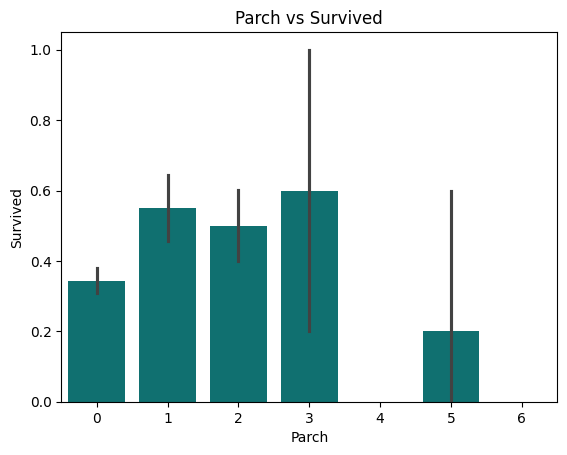

In [ ]:
sns.barplot(data, x='Parch', y='Survived', color='teal').set_title('Parch vs Survived')

Observations:

1. Here too the results are quite similar. Passengers with their parents/children onboard have greater chance of survival. It however reduces as the number goes up.

2. The chances of survival is good for somebody who has 1-3 parents/children on the ship. Being alone also proves to be fatal and the chances for survival decreases when somebody has >4 parents/children on the ship.

### Fare

In [ ]:
# Fare -> continous feature

print('Highest Fare was:', data['Fare'].max())
print('Lowest Fare was:', data['Fare'].min())
print('Average Fare was:', data['Fare'].mean())

Highest Fare was: 512.3292
Lowest Fare was: 0.0
Average Fare was: 32.204207968574636


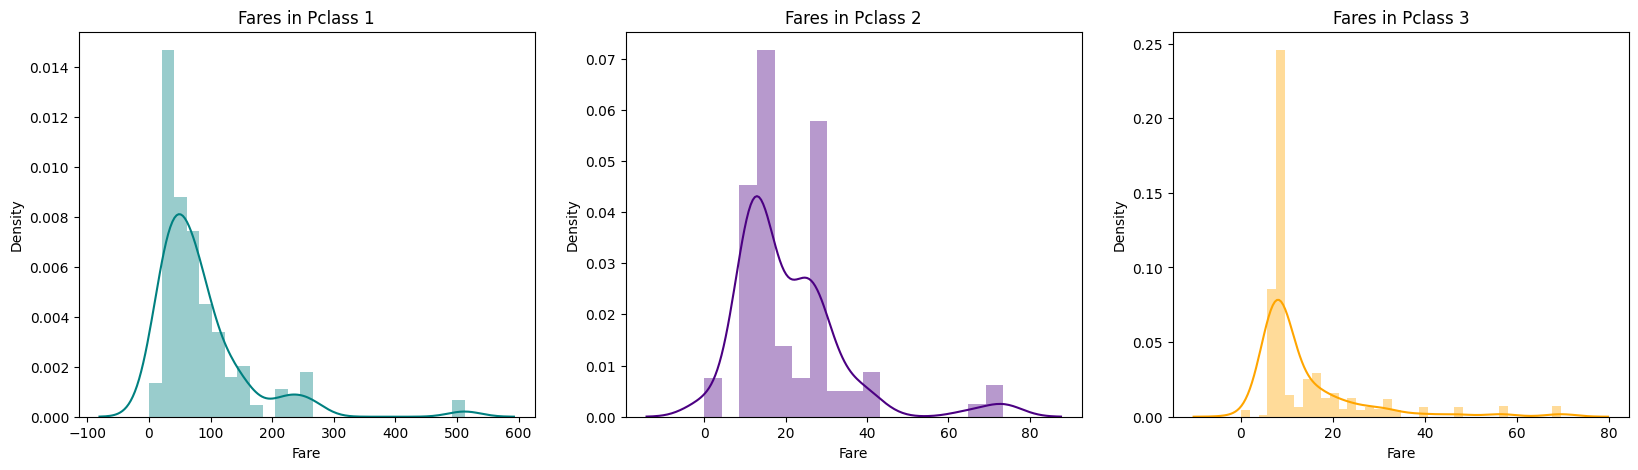

In [ ]:
f, ax = plt.subplots(1,3, figsize=(20,5))

sns.distplot(data[data['Pclass']==1].Fare, ax=ax[0], color='teal')
ax[0].set_title('Fares in Pclass 1')

sns.distplot(data[data['Pclass']==2].Fare, ax=ax[1], color='indigo')
ax[1].set_title('Fares in Pclass 2')

sns.distplot(data[data['Pclass']==3].Fare, ax=ax[2], color='orange')
ax[2].set_title('Fares in Pclass 3')

plt.show()

There looks to be a large distribution in the fares of passengers in Pclass1 and this distribution goes on decreasing as the standards reduces. As this is also continous, we can convert into discrete values by using binning.

**Observations in a Nutshell for all features:**

1. **Gender:** The chance of survival for women is high as compared to men.

2. **Pclass:**There is a visible trend that being a 1st class passenger gives you better chances of survival. The survival rate for Pclass3 is very low. For women, the chance of survival from Pclass1 is almost 1 and is high too for those from Pclass2.

3. **Age:** Children less than 5-10 years do have a high chance of survival. Passengers between age group 15 to 35 died a lot.

4. **Embarked:** This is a very interesting feature. The chances of survival at C looks to be better than even though the majority of Pclass1 passengers got up at S. Passengers at Q were all from Pclass3.

5. **Parch+SibSp:** Having 1-2 siblings/spouse on board or 1-3 parents/children shows a greater chance of probablity rather than being alone or having a large family travelling with you.

### Correlations (heatmap)

<Axes: >

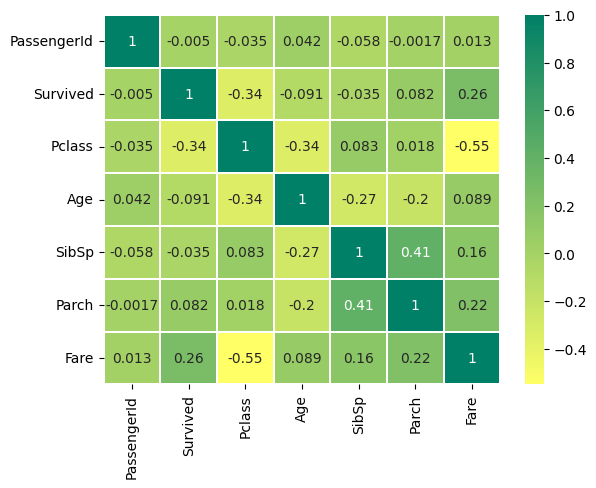

In [ ]:
data_corr = data.drop(['Name', 'Gender', 'Ticket', 'Cabin', 'Embarked', 'Initial'], axis=1)

sns.heatmap(data_corr.corr(), annot=True, cmap='summer_r', linewidths=0.2)

The first thing to note is that only the numeric features are compared as it is obvious that we cannot correlate between alphabets or strings.

Now lets say that two features are highly or perfectly correlated, so the increase in one leads to increase in the other. This means that both the features are containing highly similar information and there is very little or no variance in information. This is known as MultiColinearity as both of them contains almost the same information.

So do you think we should use both of them as one of them is redundant. While making or training models, we should try to eliminate redundant features as it reduces training time and many such advantages.

Now from the above heatmap,we can see that the features are not much correlated. The highest correlation is between SibSp and Parch i.e 0.41. So we can carry on with all features.

## Feature engineering and Data cleaning

Whenever we are given a dataset with features, **it is not necessary that all the features will be important**. There maybe be many redundant features which should be eliminated. Also we can get or add new features by observing or extracting information from other features.

An example would be getting the Initals feature using the Name feature. Lets see if we can get any new features and eliminate a few. Also we will tranform the existing relevant features to suitable form for further predictive modeling.

### Age band

**Problem With Age Feature:**

Age is a continous feature, there is a certain problem with continous variables in Machine Learning models.

Eg: We can group or arrange Person by gender, but how to group them by their Age? If there are 30 persons, there may be 30 age values. Now this is problematic.

We need to **convert these continous values into categorical values**. We can using **binning** i.e group a range of ages into a single bin or assign them a single value.

The maximum age of a passenger was 80. Let's divide the range from 0-80 into 5 bins -> 80/5 = 16 -> bins of size 16.

In [ ]:
data['Age_band']=0
data.loc[data['Age']<=16,'Age_band']=0
data.loc[(data['Age']>16)&(data['Age']<=32),'Age_band']=1
data.loc[(data['Age']>32)&(data['Age']<=48),'Age_band']=2
data.loc[(data['Age']>48)&(data['Age']<=64),'Age_band']=3
data.loc[data['Age']>64,'Age_band']=4
data.head(2)

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Initial,Age_band
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2


In [ ]:
# checking the number of passenegers in each band

data['Age_band'].value_counts().to_frame().style.background_gradient(cmap='summer')

,count
Age_band,
1,382
2,325
0,104
3,69
4,11


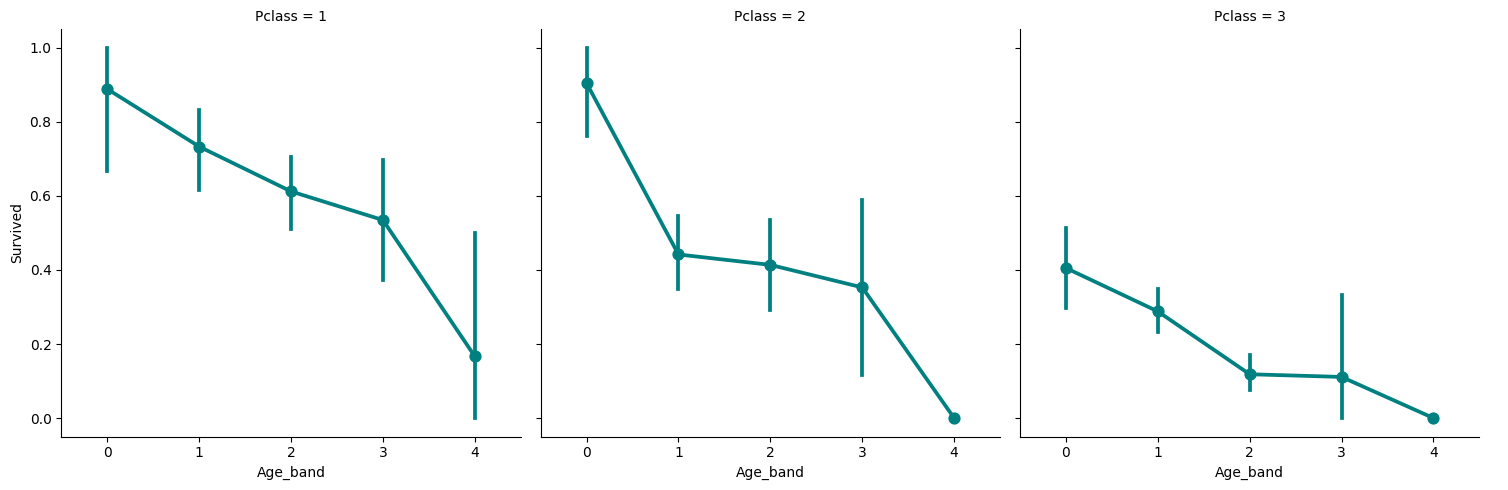

In [ ]:
sns.catplot(data, x='Age_band', y='Survived', col='Pclass', kind='point', color='teal')

### Family size

At this point, we can create a new features called **Family_size** and **Alone** and analyse it.

Family size feature is the **summation of Parch and SibSp**. It gives us a combined data so that we can check if survival rate have anything to do with family size of the passengers.

Alone will denote whether a passenger is alone or not.

In [ ]:
data['Family_Size']=0
data['Family_Size']=data['Parch']+data['SibSp']
data['Alone']=0
data.loc[data.Family_Size==0,'Alone']=1

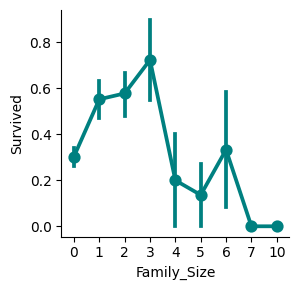

In [ ]:
sns.catplot(data, x='Family_Size',y='Survived', kind='point', color='teal', height=3)

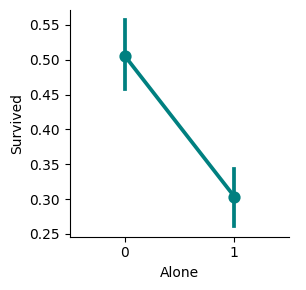

In [ ]:
sns.catplot(data, x='Alone', y='Survived', kind='point', color='teal', height=3)

**Family_Size=0 means that the passeneger is alone.**

Clearly, if you are alone or family_size=0, then chances for survival is very low. For family size > 4,the chances decrease too. This also looks to be an important feature for the model.

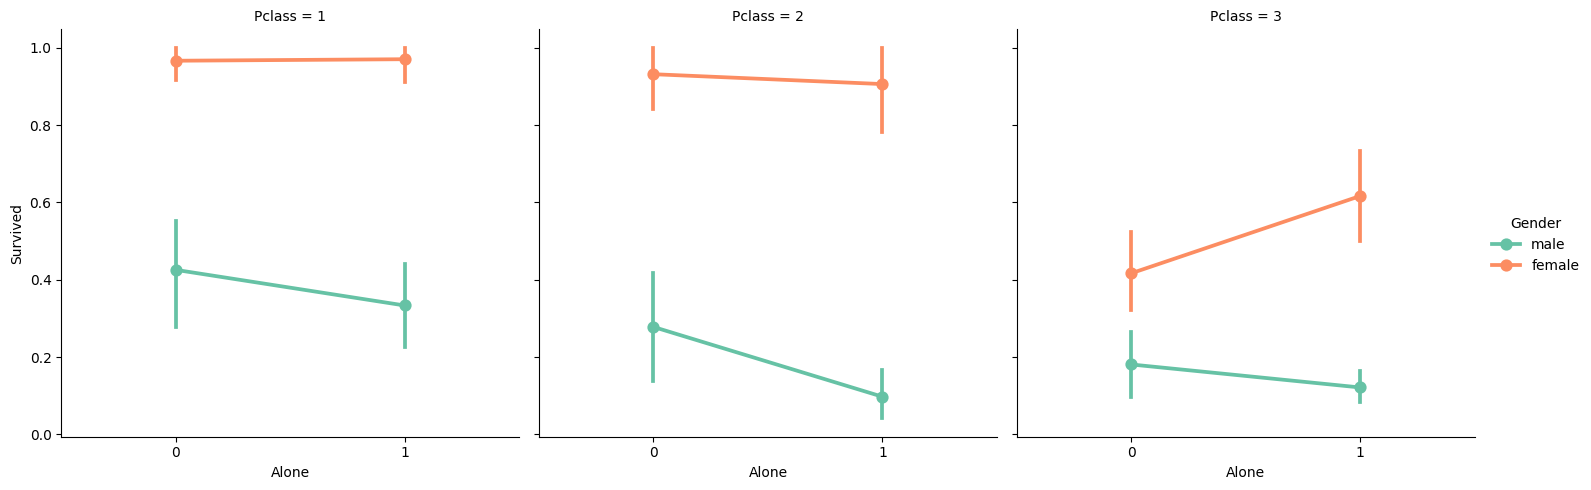

In [ ]:
sns.catplot(data, x='Alone', y='Survived', hue='Gender', col='Pclass', kind='point', palette='Set2')

It is visible that being alone is harmful irrespective of Gender or Pclass except for Pclass3 where the chances of females who are alone is high than those with family.

### Fare Range

Since Fare is also a continous feature, we need to convert it into ordinal value using pandas.qcut.

Pandas qcut splits or arranges the values according the number of bins we have passed. So if we pass for 5 bins, it will arrange the values equally spaced into 5 seperate bins or value ranges.

In [ ]:
data['Fare_Range'] = pd.qcut(data['Fare'], 4)
data.groupby(['Fare_Range'])['Survived'].mean().to_frame().style.background_gradient(cmap='summer_r')

,Survived
Fare_Range,
"(-0.001, 7.91]",0.197309
"(7.91, 14.454]",0.303571
"(14.454, 31.0]",0.454955
"(31.0, 512.329]",0.581081


As discussed above, we can clearly see that as the **fare_range** increases, the chances of survival increases.

Now we cannot pass the **fare_range** values as it is. We should convert it into singleton values same as we did in age_band

In [ ]:
data['Fare_cat'] = 0
data.loc[data['Fare']<=7.91,'Fare_cat']=0
data.loc[(data['Fare']>7.91)&(data['Fare']<=14.454),'Fare_cat']=1
data.loc[(data['Fare']>14.454)&(data['Fare']<=31),'Fare_cat']=2
data.loc[(data['Fare']>31)&(data['Fare']<=513),'Fare_cat']=3

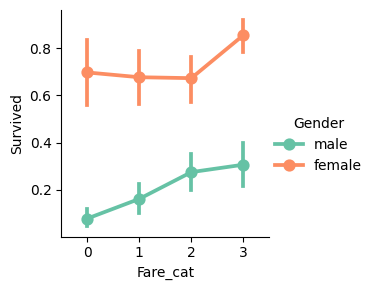

In [ ]:
sns.catplot(data, x='Fare_cat', y='Survived', hue='Gender', kind='point', palette='Set2', height=3)

Clearly, as the Fare_cat increases, the survival chances increases. This feature may become an important feature during modeling along with the Gender.

### Converting String Values into Numeric

Since we cannot pass strings to a machine learning model, we need to convert features loke Gender, Embarked, etc into numeric values

In [ ]:
data['Gender'].replace(['male','female'], [0,1], inplace=True)
data['Embarked'].replace(['S','C','Q'], [0,1,2], inplace=True)
data['Initial'].replace(['Mr','Mrs','Miss','Master'], [0,1,2,3], inplace=True)

### Dropping Features

**Name** --> We **don't need** name feature as it cannot be converted into any categorical value.

**Age** --> We have the **Age_band** feature, so no need of this.

**Ticket** --> It is any **random string** that cannot be categorised.

**Fare** --> We have the **Fare_cat** feature, so unneeded

**Cabin** --> A lot of **NaN values** and also many passengers have multiple cabins. So this is a useless feature.

**Fare_Range** --> We have the **fare_cat** feature.

**PassengerId** --> **Cannot be categorised.**

In [ ]:
data.drop(['Name','Age','Ticket','Fare','Cabin','Fare_Range','PassengerId'],axis=1,inplace=True)

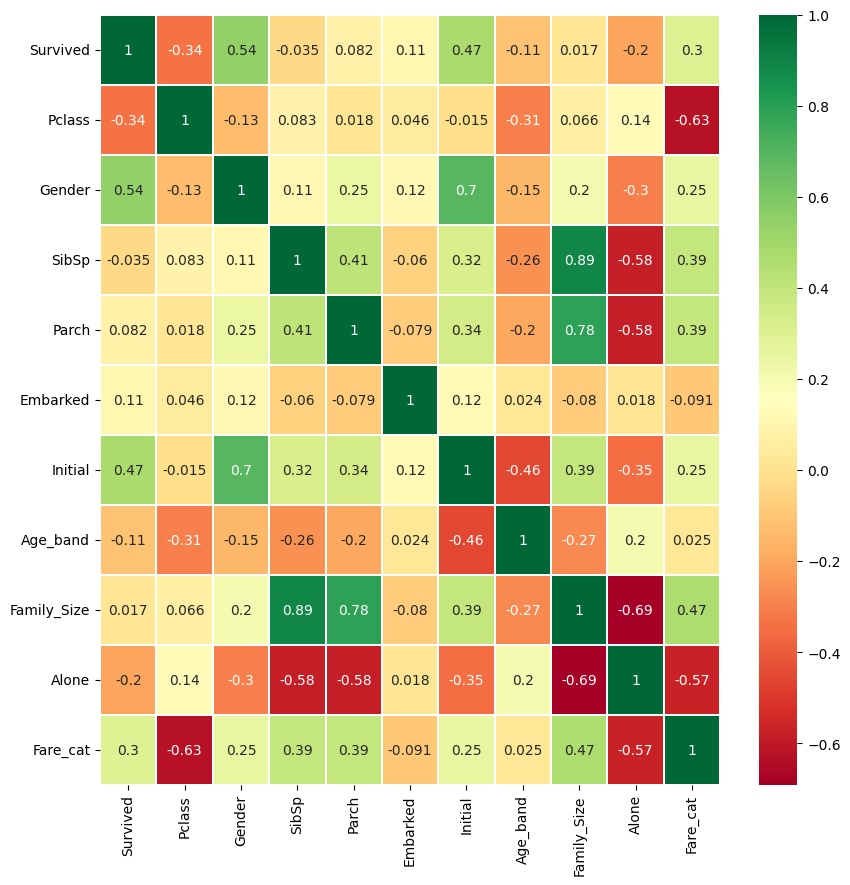

In [ ]:
sns.heatmap(data.corr(),annot=True,cmap='RdYlGn',linewidths=0.2,annot_kws={'size':10})

fig=plt.gcf()
fig.set_size_inches(10,10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

In [51]:
data.to_csv('titanic_EDA.csv', index=False)